# 02.2 — Does the Chart Auto-Encoder actually work? A Swiss roll sanity check

The Phase 02.2 Chart Auto-Encoder returned FAIL on the real embedding data. A FAIL has two
possible causes: the data has no low-dimensional chart structure, or the implementation is
broken. This notebook separates them by running the *same* `pu_manifold.cae` code on a
manifold whose answer is known in advance.

The Swiss roll is a 2-dimensional surface curled into 3-dimensional space. It is the
standard test case for manifold learning: a faithful 2-chart-dimension model should
reconstruct it almost exactly, and a model that collapsed or short-circuited will visibly
fail to.

Nothing here is pre-registered, cached, or gated. It fits in about a minute.

## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

from pu_manifold import cae

SEED = 0
N_POINTS = 3000
CHART_DIM = 2      # the Swiss roll's true intrinsic dimension
EMBED_DIM = 8
N_CHARTS = 8
HIDDEN = [64, 64]

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"cae module: {cae.__file__}")

torch 2.13.0+cpu  numpy 2.5.1
cae module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cae.py


## §2. The Swiss roll

3,000 noiseless points. Coordinates are centred and divided by a single global standard
deviation — one scalar, so the shape is preserved exactly and only the overall size changes.
The colour is the roll's own arc-length parameter `t`, so the same colour always means the
same place on the sheet: in every plot below, colour bands that stay in order mean the
surface stayed in order.

X (3000, 3)  train 2400  holdout 600


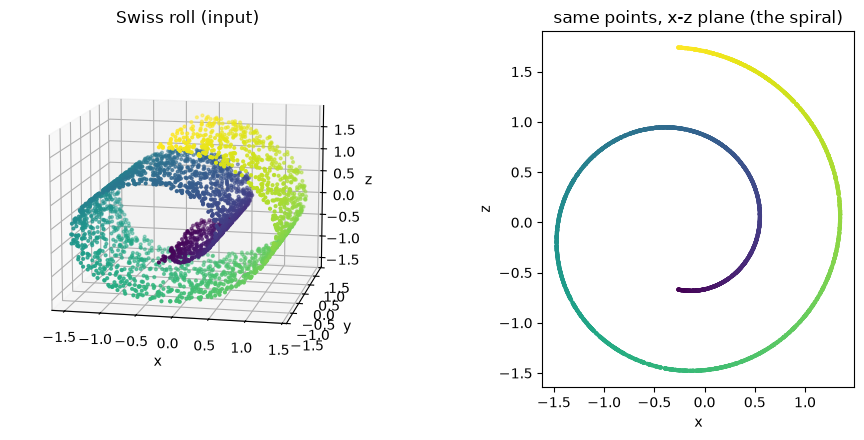

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std()

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]

print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §3. Fit the Chart Auto-Encoder

Same `cae.ChartAutoEncoder` and `cae.train_cae` Phase 02.2 used, only smaller: ambient
dimension 3 instead of 768, chart dimension 2, 8 charts, two hidden layers of 64. The
training protocol is unchanged — FPS-seeded pre-training, then AdamW on eq. 3's chart loss
plus the eq. 4 Lipschitz penalty, stopped on a plateau.

epochs_run    = 33
wallclock_s   = 26.9
early_stopped = True


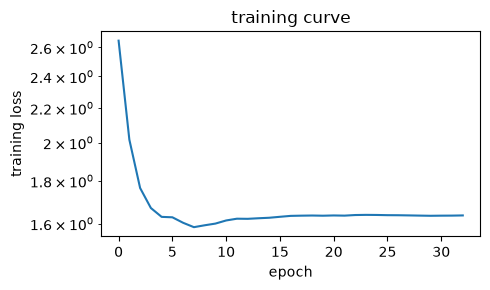

In [3]:
torch.manual_seed(SEED)
model = cae.ChartAutoEncoder(
    in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
    n_charts=N_CHARTS, hidden=HIDDEN, activation="silu",
)

cfg = {
    "seed": SEED, "lr": 1e-3, "weight_decay": 1e-4, "batch": 64,
    "max_epochs": 300, "early_stop_patience": 25, "early_stop_min_delta": 1e-4,
    "n_charts": N_CHARTS, "fps_pretrain_epochs": 20,
    "lip_weight": 1e-3, "lip_every_n_steps": 1,
}

fit = cae.train_cae(model, x_train, cfg)
model.eval()

print(f"epochs_run    = {fit['epochs_run']}")
print(f"wallclock_s   = {fit['wallclock_s']:.1f}")
print(f"early_stopped = {fit['early_stopped']}")

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("training curve")
plt.tight_layout()
plt.show()

## §4. The reconstruction, side by side

Each point is encoded, routed to its highest-probability chart, and decoded back to 3-D
through that chart's decoder and the shared embedding decoder — `model.reconstruct`, the
same argmax-chart path Phase 02.2 measured.

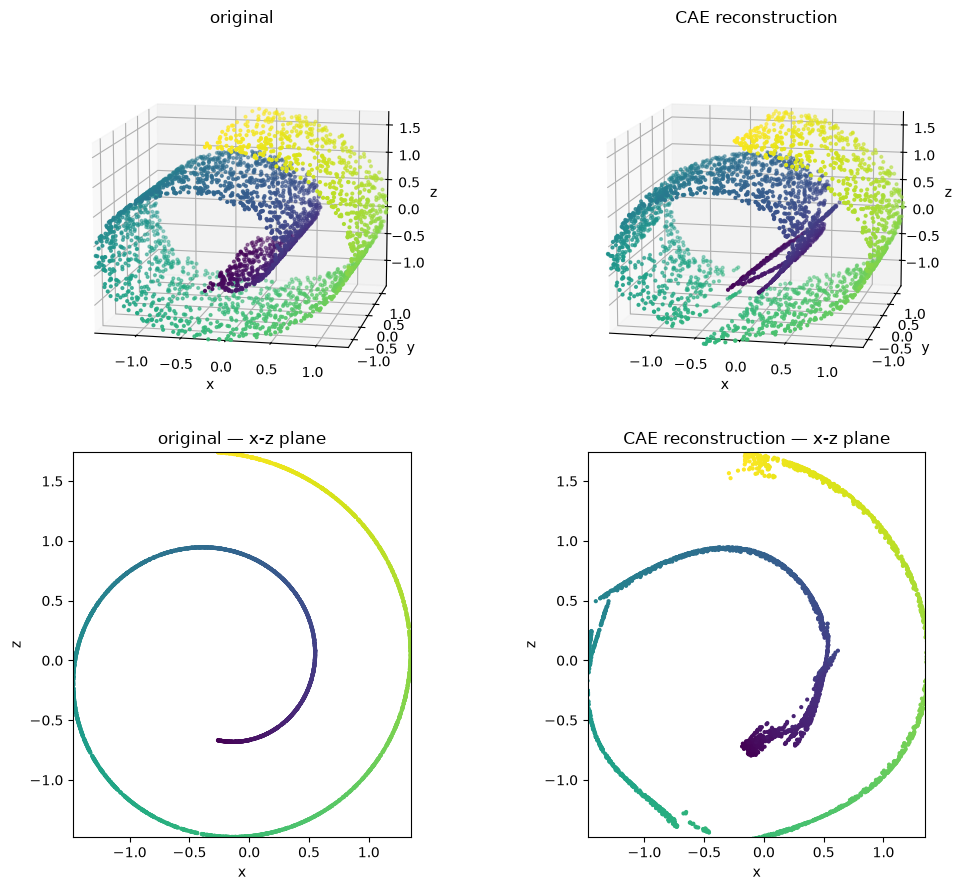

In [4]:
with torch.no_grad():
    y_all = model.reconstruct(x_all).numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X, "original"), (y_all, "CAE reconstruction")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title} — x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §5. How faithful is it, in numbers

Three questions, one number each.

1. **How far off is a reconstructed point?** Mean relative error, on held-out points the
   model never trained on.
2. **Did the atlas buy anything?** The same comparison Phase 02.2's T3 gate makes: a plain
   single-chart auto-encoder with a 2-dimensional bottleneck, same width, same depth, same
   training protocol. If the CAE is not clearly better here, the chart machinery is doing
   nothing.
3. **How many charts survived?** Charts are pruned a posteriori by decoder weight mass. A
   collapse to one chart would mean the atlas never formed.

In [5]:
with torch.no_grad():
    y_holdout = model.reconstruct(x_holdout)

cae_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout.double())
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)

# baseline: plain AE, 2-D bottleneck, matched width/depth
torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, CHART_DIM, hidden=tuple(HIDDEN), activation="silu")
plain_fit = cae.train_plain_ae(plain, x_train, {
    "seed": SEED, "lr": 1e-3, "weight_decay": 1e-4, "batch": 64,
    "max_epochs": 300, "early_stop_patience": 25, "early_stop_min_delta": 1e-4,
})
plain.eval()
with torch.no_grad():
    y_plain = plain(x_holdout)["y"]
plain_stats = cae.reconstruction_stats(x_holdout.double(), y_plain.double())

survival = cae.chart_survival(model, prune_tol=1e-2)

print("=== held-out reconstruction ===")
print(f"CAE          mse_per_dim = {cae_stats['mse_per_dim']:.6f}")
print(f"plain AE (d={CHART_DIM})  mse_per_dim = {plain_stats['mse_per_dim']:.6f}")
print(f"CAE mean relative error   = {rel_err:.4f}  ({100 * rel_err:.1f}% of point norm)")
print(f"CAE is {plain_stats['mse_per_dim'] / cae_stats['mse_per_dim']:.1f}x better than the plain AE")
print()
print("=== charts ===")
print(f"surviving = {survival['n_charts_surviving']} / {survival['n_charts_initial']}")

=== held-out reconstruction ===
CAE          mse_per_dim = 0.002092
plain AE (d=2)  mse_per_dim = 0.004575
CAE mean relative error   = 0.0484  (4.8% of point norm)
CAE is 2.2x better than the plain AE

=== charts ===
surviving = 8 / 8


## §6. Where the charts went

Left: each point coloured by which chart claimed it. A working atlas partitions the sheet
into connected patches — neighbouring points land in the same chart, and the patches tile
the roll without one chart swallowing everything.

Right: the chart coordinates themselves, for the three largest charts. Each chart encoder
ends in a sigmoid, so its coordinates live in the unit square. A chart that spreads across
its square is parameterising a real patch of surface; one collapsed to a point or a line is
not.

points per chart: [239, 3, 750, 55, 361, 188, 393, 1011]


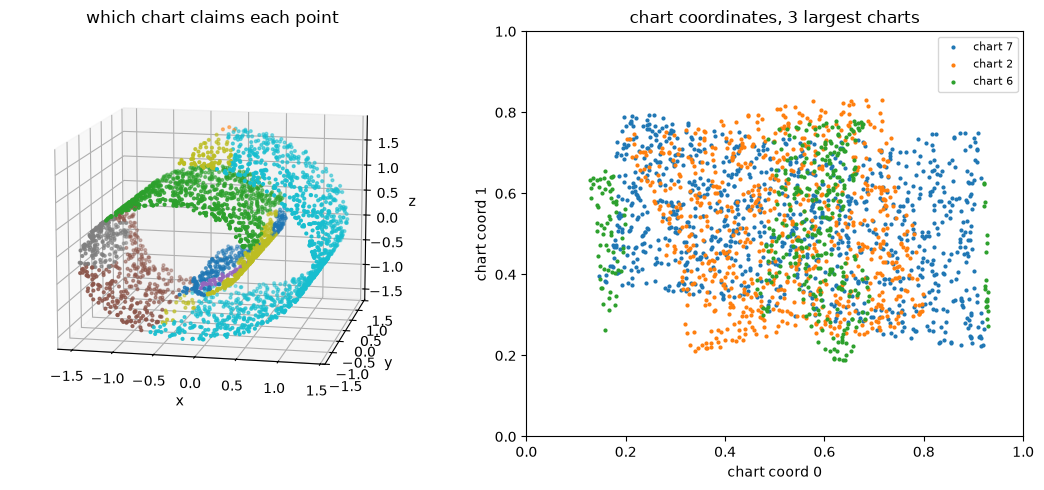

In [6]:
with torch.no_grad():
    out = model(x_all)
    chart_of = out["p"].argmax(dim=1).numpy()
    coords = out["z_charts"].numpy()  # (n, n_charts, chart_dim)

counts = np.bincount(chart_of, minlength=N_CHARTS)
print("points per chart:", counts.tolist())

fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=chart_of, cmap="tab10", s=4)
ax.view_init(**VIEW)
ax.set_title("which chart claims each point")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
for alpha in np.argsort(-counts)[:3]:
    mask = chart_of == alpha
    ax2.scatter(coords[mask, alpha, 0], coords[mask, alpha, 1], s=4, label=f"chart {alpha}")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.set_xlabel("chart coord 0"); ax2.set_ylabel("chart coord 1")
ax2.set_title("chart coordinates, 3 largest charts")
ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## §7. Read-out

The check is deliberately blunt: if the plots above show the roll reconstructed with its
colour bands in order, and the CAE beats a matched plain auto-encoder by a wide margin,
then the implementation recovers a known 2-dimensional manifold and the Phase 02.2 FAIL is
about the data, not the code. If the reconstruction is a blob, a plane, or a roll with its
colours scrambled, the code is what failed.

In [7]:
faithful = (
    rel_err < 0.10
    and cae_stats["mse_per_dim"] < plain_stats["mse_per_dim"]
    and survival["n_charts_surviving"] > 1
)

print(f"relative error < 10%          : {rel_err < 0.10}   ({100 * rel_err:.1f}%)")
print(f"beats matched plain AE        : {cae_stats['mse_per_dim'] < plain_stats['mse_per_dim']}")
print(f"more than one chart survived  : {survival['n_charts_surviving'] > 1}"
      f"   ({survival['n_charts_surviving']}/{survival['n_charts_initial']})")
print()
print(f"Swiss roll recovered: {faithful}")
print()
if faithful:
    print(
        "The implementation reconstructs a known 2-dimensional manifold to within a few\n"
        "percent, using more than one chart, and beats a matched single-chart baseline.\n"
        "Phase 02.2's FAIL is therefore a statement about the embedding data, not evidence\n"
        "of a broken Chart Auto-Encoder."
    )
else:
    print(
        "The implementation did NOT recover the Swiss roll. Phase 02.2's FAIL cannot be\n"
        "attributed to the data until this is explained."
    )

relative error < 10%          : True   (4.8%)
beats matched plain AE        : True
more than one chart survived  : True   (8/8)

Swiss roll recovered: True

The implementation reconstructs a known 2-dimensional manifold to within a few
percent, using more than one chart, and beats a matched single-chart baseline.
Phase 02.2's FAIL is therefore a statement about the embedding data, not evidence
of a broken Chart Auto-Encoder.
